# Data Analysis: Vehicle Adoption Dataset

In this section, we will load the dataset `McGill_SAAQ_2020_2024-01-10.csv`, perform an initial exploration, and visualize key features to understand the data.

In [ ]:
# Import required libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import geopandas as gpd
import unicodedata
import re

In [ ]:
# Import required libraries
import pandas as pd

# Load the dataset (try common encodings)
file_path = "/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/SAQ data/McGill_SAAQ_2020_2024-01-10.csv"
df = pd.read_csv(file_path, encoding='utf-16', sep=';', low_memory=False)
#df.head()

In [ ]:
df.head()

In [ ]:
# Show basic info and summary statistics
df.info()

In [ ]:
# Show summary statistics for numeric columns
df.describe()

In [ ]:
# Visualize distributions of key numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

df[numeric_cols].hist(figsize=(15, 8), bins=20, layout=(2, min(4, len(numeric_cols))))
plt.suptitle('Distributions of Numeric Features')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# Visualize categorical features (if any) in subplots
import math

categorical_cols = df.select_dtypes(include=['object', 'category']).columns
n_cols = 5
n = len(categorical_cols)
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten() if n > 1 else [axes]

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# STEP 0 — Clean and prepare key variables
First, clean fuel type and convert numeric columns.

In [ ]:
# Clean decimal comma columns
for col in ['TC', 'TC_ville', 'TC_route', 'TCPP', 'TE']:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(',', '.', regex=False)
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Standardize fuel type
def classify_fuel(row):
    carb = str(row['CARB']).upper()
    motor = str(row['Motorisation']).upper()

    if 'ELECT' in motor or 'ELEC' in carb:
        return 'Electric'
    if carb == 'H':
        return 'Hybrid'
    if carb == 'D':
        return 'Diesel'
    return 'Gasoline'

df['FuelType'] = df.apply(classify_fuel, axis=1)

# Vehicle age
df['VehicleAge'] = df['AnneeSAAQ'] - df['ANV']

# 1. ADOPTION OVER TIME
A. Fleet share by fuel type per year (stock)

In [ ]:
share_year = (
    df.groupby(['AnneeSAAQ', 'FuelType'])
      .size()
      .reset_index(name='Count')
)

total_year = (
    df.groupby('AnneeSAAQ')
      .size()
      .reset_index(name='Total')
)

share_year = share_year.merge(total_year, on='AnneeSAAQ')
share_year['Share'] = share_year['Count'] / share_year['Total']

for fuel in share_year['FuelType'].unique():
    subset = share_year[share_year['FuelType'] == fuel]
    plt.plot(subset['AnneeSAAQ'], subset['Share'])

plt.xlabel('Year')
plt.ylabel('Fleet Share')
plt.title('Fleet Fuel Share Over Time')
plt.show()

B. Adoption among entrants only (true adoption signal)

In [ ]:
df_new = df[df['Entrant'] == 1]

share_new = (
    df_new.groupby(['AnneeSAAQ', 'FuelType'])
          .size()
          .reset_index(name='Count')
)

total_new = (
    df_new.groupby('AnneeSAAQ')
          .size()
          .reset_index(name='Total')
)

share_new = share_new.merge(total_new, on='AnneeSAAQ')
share_new['Share'] = share_new['Count'] / share_new['Total']

for fuel in share_new['FuelType'].unique():
    subset = share_new[share_new['FuelType'] == fuel]
    plt.plot(subset['AnneeSAAQ'], subset['Share'])

plt.xlabel('Year')
plt.ylabel('Share of New Registrations')
plt.title('Fuel Share Among New Vehicles')
plt.show()

# 2. SPATIAL DISTRIBUTION

A. EV share by region in latest year

In [ ]:
latest_year = df['AnneeSAAQ'].max()
df_latest = df[df['AnneeSAAQ'] == latest_year]

region_share = (
    df_latest.groupby(['Region', 'FuelType'])
             .size()
             .reset_index(name='Count')
)

total_region = (
    df_latest.groupby('Region')
             .size()
             .reset_index(name='Total')
)

region_share = region_share.merge(total_region, on='Region')
region_share['Share'] = region_share['Count'] / region_share['Total']

# Plot share of all fuel types by region
pivot = region_share.pivot(index='Region', columns='FuelType', values='Share').fillna(0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]  # sort by total

pivot.plot(kind='bar', stacked=True, figsize=(14, 6))
plt.xlabel('Region')
plt.ylabel('Share')
plt.title(f'Vehicle Fuel Type Share by Region ({latest_year})')
plt.legend(title='Fuel Type')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
fuel_types = pivot.columns.tolist()
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for i, fuel in enumerate(fuel_types):
    axes[i].bar(pivot.index, pivot[fuel])
    axes[i].set_title(f'{fuel} Share')
    axes[i].set_ylabel('Share')
    axes[i].tick_params(axis='x', rotation=90)

# If fewer than 4 fuels, hide unused axes
for j in range(len(fuel_types), 4):
    axes[j].axis('off')

plt.suptitle(f'Fuel Type Share by Region — {latest_year}')
plt.tight_layout()
plt.show()

B. Spatial distribution of the vehicles

In [ ]:
# ---------------------------
# 1. Load Quebec regions
# ---------------------------
regions_gdf = gpd.read_file("quebec_regions.geojson")

# ---------------------------
# 2. Clean region names
# ---------------------------
def clean_region_name(text):
    if pd.isna(text):
        return text
    text = str(text)
    text = re.sub(r'^\d+\.\s*', '', text)  # remove numeric prefix like "06. "
    text = unicodedata.normalize('NFKD', text)
    text = text.encode('ascii', 'ignore').decode('utf-8')
    text = text.lower()
    text = re.sub(r'-+', '-', text)
    text = re.sub(r'\s*-\s*', '-', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

regions_gdf['Region_norm'] = regions_gdf['res_nm_reg'].apply(clean_region_name)

# ---------------------------
# 3. Select latest year
# ---------------------------
latest_year = df['AnneeSAAQ'].max()
df_latest = df[df['AnneeSAAQ'] == latest_year].copy()

df_latest['Region_norm'] = df_latest['Region'].apply(clean_region_name)

# ---------------------------
# 4. Compute fuel shares
# ---------------------------
region_stats = (
    df_latest.groupby(['Region_norm', 'FuelType'])
             .size()
             .reset_index(name='Count')
)

total_region = (
    df_latest.groupby('Region_norm')
             .size()
             .reset_index(name='Total')
)

region_stats = region_stats.merge(total_region, on='Region_norm')
region_stats['Share'] = region_stats['Count'] / region_stats['Total']

# Remove unknown region if present
region_stats = region_stats[
    region_stats['Region_norm'] != 'inconnu ou hors quebec'
]

# ---------------------------
# 5. Plot 4 choropleth maps
# ---------------------------
fuel_types = region_stats['FuelType'].unique()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, fuel in enumerate(fuel_types):
    fuel_data = region_stats[region_stats['FuelType'] == fuel]

    map_gdf = regions_gdf.merge(
        fuel_data[['Region_norm', 'Share']],
        on='Region_norm',
        how='left'
    )

    map_gdf['Share'] = map_gdf['Share'].fillna(0)

    map_gdf.plot(
        column='Share',
        cmap='viridis',
        linewidth=0.5,
        edgecolor='black',
        legend=True,
        ax=axes[i]
    )

    axes[i].set_title(f'{fuel} Share')
    axes[i].axis('off')

# Hide empty subplots if fewer than 4 fuels
for j in range(len(fuel_types), 4):
    axes[j].axis('off')

plt.suptitle(f'Fuel Type Share by Region — {latest_year}', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# =====================================================
# EV SHARE PER FSA — ZOOMED TO MONTREAL ISLAND
# =====================================================

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
import re

# --- Clean region name ---
def clean_region_name(text):
    if pd.isna(text):
        return text
    text = str(text)
    text = re.sub(r'^\d+\.\s*', '', text)
    text = unicodedata.normalize('NFKD', text)
    text = text.encode('ascii', 'ignore').decode('utf-8')
    text = text.lower()
    text = re.sub(r'-+', '-', text)
    text = re.sub(r'\s*-\s*', '-', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# --- Load Montreal FSA geometry ---
mtl_gdf = gpd.read_file(
    "/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model/Montreal.geojson"
)

mtl_gdf['CFSAUID'] = mtl_gdf['CFSAUID'].astype(str).str.upper()

# --- Filter dataset to Montréal ---
latest_year = df['AnneeSAAQ'].max()
df_latest = df[df['AnneeSAAQ'] == latest_year].copy()

df_latest['Region_norm'] = df_latest['Region'].apply(clean_region_name)
montreal_df = df_latest[df_latest['Region_norm'] == 'montreal'].copy()

montreal_df = montreal_df[montreal_df['RTA'].notna()]
montreal_df['RTA'] = montreal_df['RTA'].astype(str).str.upper()

# --- Compute EV share per FSA ---
rta_stats = (
    montreal_df.groupby(['RTA', 'FuelType'])
               .size()
               .reset_index(name='Count')
)

total_rta = (
    montreal_df.groupby('RTA')
               .size()
               .reset_index(name='Total')
)

rta_stats = rta_stats.merge(total_rta, on='RTA')
rta_stats['Share'] = rta_stats['Count'] / rta_stats['Total']

ev_rta = rta_stats[rta_stats['FuelType'] == 'Electric'].copy()

# --- Merge ---
map_gdf = mtl_gdf.merge(
    ev_rta[['RTA', 'Share']],
    left_on='CFSAUID',
    right_on='RTA',
    how='inner'   # <--- only keep FSAs that exist in Montreal dataset
)

map_gdf['Share'] = map_gdf['Share'].fillna(0)

# --- Zoom extent to island ---
xmin, ymin, xmax, ymax = map_gdf.total_bounds

# Add small margin
buffer_x = (xmax - xmin) * 0.05
buffer_y = (ymax - ymin) * 0.05

fig, ax = plt.subplots(figsize=(8, 10))

map_gdf.plot(
    column='Share',
    cmap='viridis',
    linewidth=0.2,
    edgecolor='black',
    legend=True,
    ax=ax
)

ax.set_xlim(xmin - buffer_x, xmax + buffer_x)
ax.set_ylim(ymin - buffer_y, ymax + buffer_y)

ax.set_title(f'EV Share by FSA — Montréal Island ({latest_year})')
ax.axis('off')

plt.show()

# 3. STRUCTURAL PATTERNS

A. Adoption by age group

In [ ]:
age_share = (
    df_latest.groupby(['AgeProprio (groupes)', 'FuelType'])
             .size()
             .reset_index(name='Count')
)

total_age = (
    df_latest.groupby('AgeProprio (groupes)')
             .size()
             .reset_index(name='Total')
)

age_share = age_share.merge(total_age, on='AgeProprio (groupes)')
age_share['Share'] = age_share['Count'] / age_share['Total']

ev_age = age_share[age_share['FuelType'] == 'Electric']

plt.bar(ev_age['AgeProprio (groupes)'], ev_age['Share'])
plt.xticks(rotation=45)
plt.xlabel('Owner Age Group')
plt.ylabel('EV Share')
plt.title('EV Share by Owner Age Group')
plt.show()

B. Vehicle age distribution by fuel type

In [ ]:
# Plot vehicle age distribution by fuel type with legend
for fuel in df_latest['FuelType'].unique():
    subset = df_latest[df_latest['FuelType'] == fuel]
    plt.hist(subset['VehicleAge'], bins=20, alpha=0.6, label=fuel)

plt.xlabel('Vehicle Age')
plt.ylabel('Count')
plt.title('Vehicle Age Distribution by Fuel Type')
plt.legend(title='Fuel Type')
plt.show()

# 4. PREDICTION

In [ ]:

file_path = "/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/SAQ data/McGill_SAAQ_2013_2024-01-10.csv"
df = pd.read_csv(file_path, encoding='utf-16', sep=';', low_memory=False)
df = (df
      .loc[:, ['RTA', 'Genre', 'AgeProprio (groupes)', 'Hybrid Type', 'Motorisation', 'Classe principale', 'Usage']]
      .rename(columns={'RTA': 'fsa', 'Genre': 'gender', 'AgeProprio (groupes)': 'age_group'})
      .query("Usage != 'Commercial' and age_group != 'Commercial'")
      .dropna(subset=['gender', 'Classe principale'])
      .drop(columns=['Usage'])
      .copy())

age_mapping = {
    '19 ans et moins': pd.Interval(0, 20, closed='left'),
    '20 à 29 ans': pd.Interval(20, 30, closed='left'),
    '30 à 39 ans': pd.Interval(30, 40, closed='left'),
    '40 à 49 ans': pd.Interval(40, 50, closed='left'),
    '50 à 59 ans': pd.Interval(50, 60, closed='left'),
    '60 ans et plus': pd.Interval(60, 120, closed='left')
}
df['age_group'] = df['age_group'].map(age_mapping)


def get_vehicle_type(row):

    h_type = str(row.get('Hybrid Type')).lower().strip()
    motor = str(row.get('Motorisation', '')).lower().strip()
    c_main = str(row.get('Classe principale', '')).lower().strip()

    is_sedan = any(x in c_main for x in ['compacte', 'sous-sompacte', 'intermediaire', 'minicompacte', 'grande berline', 'deux places'])
    is_suv = any(x in c_main for x in ['familiale', 'fourgonnette', 'vus'])
    is_pickup_van = any(x in c_main for x in ['camionnette', 'vehicule à usage spécial', 'fourgon'])

    if h_type == "" and motor == "":
        return 'unknow'
    
    if motor == 'electrique':
        return 'electric'

    is_hybrid = (motor in ['hybride', 'hybride branchable']) or (motor == "" and h_type != "") 

    is_icev = motor in ['diesel', 'essence', 'gaz naturel']

    if is_hybrid:
        if is_suv:
            return 'hev_suv'
        if is_sedan:
            return 'hev_sedan'
        if is_pickup_van:
            return 'hev_van/pickup'
    
    elif is_icev:
        if is_pickup_van:
            return 'ice_van/pickup'
        if is_suv:
            return 'ice_suv'
        if is_sedan:
            return 'ice_sedan'
    


df['vehicle_type'] = df.apply(get_vehicle_type, axis=1)
df = df.drop(columns=['Hybrid Type', 'Motorisation', 'Classe principale']).query("vehicle_type != 'hev_van/pickup' and vehicle_type != 'unknow'")


veh_dist = (
    df.groupby(['fsa', 'gender', 'age_group'])['vehicle_type']
    .value_counts(normalize=True)
    .reset_index(name='proportion')
)

pivot_veh_dist = veh_dist.pivot_table(
    index=['fsa', 'gender', 'age_group'], 
    columns='vehicle_type', 
    values='proportion', 
    fill_value=0
)
pivot_veh_dist = pivot_veh_dist.sort_index()

if __name__ == "__main__":
    print("Testing distribution output...")
    print(pivot_veh_dist.head())
    #pivot_veh_dist.to_parquet(os.path.join(base_dir, 'veh_dist.parquet'))

In [ ]:
# =====================================================
# YEAR-OVER-YEAR CHANGE BY VEHICLE TYPE — ALL CSV FILES
# =====================================================

import os
import glob
import re
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import unicodedata

# --- 1. Helpers ---
def normalize(text):
    text = unicodedata.normalize('NFKD', str(text))
    text = text.encode('ascii', 'ignore').decode('utf-8')
    return text.lower().strip()

def get_vehicle_type(row):
    h_type = normalize(row.get('Hybrid Type', ''))
    motor  = normalize(row.get('Motorisation', ''))
    c_main = normalize(row.get('Classe principale', ''))

    is_sedan      = any(x in c_main for x in ['compacte', 'sous-compacte', 'intermediaire', 'minicompacte', 'grande berline', 'deux places'])
    is_suv        = any(x in c_main for x in ['familiale', 'fourgonnette', 'vus'])
    is_pickup_van = any(x in c_main for x in ['camionnette', 'vehicule a usage special', 'fourgon'])

    if h_type == '' and motor == '':
        return 'unknown'
    if motor == 'electrique':
        return 'electric'

    is_hybrid = (motor in ['hybride', 'hybride branchable']) or (motor == '' and h_type != '')
    is_icev   = motor in ['diesel', 'essence', 'gaz naturel']

    if is_hybrid:
        if is_suv:        return 'hev_suv'
        if is_sedan:      return 'hev_sedan'
        if is_pickup_van: return 'hev_van/pickup'
    elif is_icev:
        if is_pickup_van: return 'ice_van/pickup'
        if is_suv:        return 'ice_suv'
        if is_sedan:      return 'ice_sedan'

    return 'other'

# --- 2. Discover all CSV files in SAQ data folder ---
saq_dir = "/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/SAQ data"
csv_files = sorted(glob.glob(os.path.join(saq_dir, "*.csv")))

print(f"Found {len(csv_files)} files:")
for f in csv_files:
    print(f"  {os.path.basename(f)}")

# --- 3. Load and tag each file with its year (retry on timeout) ---
COLS = ['AnneeSAAQ', 'Hybrid Type', 'Motorisation', 'Classe principale',
        'Usage', 'AgeProprio (groupes)']

def read_csv_with_retries(path, retries=3, wait_s=3):
    last_err = None
    for attempt in range(1, retries + 1):
        try:
            return pd.read_csv(path, encoding='utf-16', sep=';', low_memory=False)
        except Exception as e:
            last_err = e
            print(f"  ⚠️ Attempt {attempt}/{retries} failed for {os.path.basename(path)}: {e}")
            if attempt < retries:
                time.sleep(wait_s * attempt)
    raise last_err

frames = []
failed_files = []

for path in csv_files:
    try:
        df_raw = read_csv_with_retries(path, retries=3, wait_s=2)

        available = [c for c in COLS if c in df_raw.columns]
        df_raw = df_raw[available].copy()

        if 'AnneeSAAQ' not in df_raw.columns:
            fname = os.path.basename(path)
            year_match = re.search(r'(\d{4})', fname)
            if year_match:
                df_raw['AnneeSAAQ'] = int(year_match.group(1))

        frames.append(df_raw)
        print(f"  ✅ Loaded {os.path.basename(path)} — {len(df_raw):,} rows")

    except Exception as e:
        failed_files.append((os.path.basename(path), str(e)))
        print(f"  ❌ Skipped {os.path.basename(path)} after retries: {e}")

if not frames:
    raise RuntimeError("No CSV files could be loaded.")

all_years = pd.concat(frames, ignore_index=True)

print(f"\nTotal rows across loaded files: {len(all_years):,}")
print(f"Years found: {sorted(all_years['AnneeSAAQ'].dropna().unique().astype(int))}")

if failed_files:
    print("\nFiles that failed:")
    for f, err in failed_files:
        print(f"  - {f}: {err}")

# --- 4. Filter & classify ---
all_years = (all_years
    .query("Usage != 'Commercial' and `AgeProprio (groupes)` != 'Commercial'"
           if 'Usage' in all_years.columns and 'AgeProprio (groupes)' in all_years.columns
           else "index == index")   # no-op fallback
    .dropna(subset=['Classe principale'])
    .copy()
)

all_years['vehicle_type'] = all_years.apply(get_vehicle_type, axis=1)

all_years = all_years[
    ~all_years['vehicle_type'].isin(['unknown', 'other', 'hev_van/pickup'])
]

# --- 5. Count per year × vehicle type ---
yearly_counts = (
    all_years.groupby(['AnneeSAAQ', 'vehicle_type'])
             .size()
             .reset_index(name='count')
             .sort_values(['vehicle_type', 'AnneeSAAQ'])
)

yearly_counts['abs_change']   = yearly_counts.groupby('vehicle_type')['count'].diff()
yearly_counts['growth_rate']  = yearly_counts.groupby('vehicle_type')['count'].pct_change()

# --- 6. Summary tables ---
pivot_counts = (yearly_counts
    .pivot(index='AnneeSAAQ', columns='vehicle_type', values='count')
    .fillna(0).astype(int)
)

pivot_growth = (yearly_counts
    .pivot(index='AnneeSAAQ', columns='vehicle_type', values='growth_rate')
    .mul(100).round(1)
)

print("\n--- Vehicle Count by Year ---")
print(pivot_counts.to_string())

print("\n--- Growth Rate (%) by Year ---")
print(pivot_growth.to_string())

# --- 7. Plot: absolute counts ---
vehicle_types = yearly_counts['vehicle_type'].unique()
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(13, 5))
for i, vt in enumerate(vehicle_types):
    s = yearly_counts[yearly_counts['vehicle_type'] == vt]
    ax.plot(s['AnneeSAAQ'], s['count'], marker='o', label=vt, color=colors[i % 10])

ax.set_title('Vehicle Count per Type — All Years')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.legend(title='Vehicle Type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

# --- 8. Plot: absolute year-over-year change ---
fig, ax = plt.subplots(figsize=(13, 5))
for i, vt in enumerate(vehicle_types):
    s = yearly_counts[yearly_counts['vehicle_type'] == vt].dropna(subset=['abs_change'])
    ax.plot(s['AnneeSAAQ'], s['abs_change'], marker='o', label=vt, color=colors[i % 10])

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Year-over-Year Absolute Change by Vehicle Type')
ax.set_xlabel('Year')
ax.set_ylabel('Δ Count')
ax.legend(title='Vehicle Type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

# --- 9. Plot: growth rate (%) ---
fig, ax = plt.subplots(figsize=(13, 5))
for i, vt in enumerate(vehicle_types):
    s = yearly_counts[yearly_counts['vehicle_type'] == vt].dropna(subset=['growth_rate'])
    ax.plot(s['AnneeSAAQ'], s['growth_rate'], marker='o', label=vt, color=colors[i % 10])

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
ax.set_title('Year-over-Year Growth Rate by Vehicle Type')
ax.set_xlabel('Year')
ax.set_ylabel('Growth Rate')
ax.legend(title='Vehicle Type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

In [ ]:
# --- Predict vehicle share from yearly growth rates ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, HuberRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor

def make_growth_model(model_name="ridge"):
    if model_name == "linear":
        return LinearRegression()
    if model_name == "ridge":
        return Ridge(alpha=1.0)
    if model_name == "huber":
        return HuberRegressor(epsilon=1.35, alpha=0.0001)
    if model_name == "poly2_ridge":
        return make_pipeline(PolynomialFeatures(degree=2, include_bias=False), Ridge(alpha=1.0))
    if model_name == "rf":
        return RandomForestRegressor(
            n_estimators=300, random_state=42, min_samples_leaf=2
        )
    raise ValueError(f"Unknown model_name: {model_name}")

model_name = "ridge"  # try: linear, ridge, huber, poly2_ridge, rf

# 1) Historical counts matrix (year x vehicle_type)
counts_hist = (
    yearly_counts
    .pivot(index='AnneeSAAQ', columns='vehicle_type', values='count')
    .fillna(0)
    .sort_index()
)
counts_hist.index = counts_hist.index.astype(int)

# 2) Historical growth rates from counts
growth_hist = counts_hist.pct_change().replace([np.inf, -np.inf], np.nan)

# 3) Forecast settings
horizon_years = 10
min_history_points = 4
growth_clip = (-0.80, 2.00)   # avoid extreme/unstable forecasts

last_year = int(counts_hist.index.max())
future_years = np.arange(last_year + 1, last_year + horizon_years + 1)

pred_growth = pd.DataFrame(index=future_years, columns=counts_hist.columns, dtype=float)

# 4) Fit one model per vehicle type: growth_rate ~ year
for vt in counts_hist.columns:
    s = growth_hist[vt].dropna()
    if len(s) >= min_history_points:
        X = s.index.values.reshape(-1, 1)
        y = s.values
        model = make_growth_model(model_name)
        model.fit(X, y)
        g = model.predict(future_years.reshape(-1, 1))
    elif len(s) > 0:
        g = np.repeat(s.mean(), len(future_years))
    else:
        g = np.zeros(len(future_years))

    pred_growth[vt] = np.clip(g, growth_clip[0], growth_clip[1])

# 5) Recursive count forecast from predicted growth
counts_future = pd.DataFrame(index=future_years, columns=counts_hist.columns, dtype=float)
prev = counts_hist.iloc[-1].astype(float).copy()

for y in future_years:
    g = pred_growth.loc[y].fillna(0.0)
    nxt = prev * (1.0 + g)
    nxt = nxt.clip(lower=0.0)
    counts_future.loc[y] = nxt
    prev = nxt

# 6) Convert to shares
share_hist = counts_hist.div(counts_hist.sum(axis=1), axis=0)
share_future = counts_future.div(counts_future.sum(axis=1), axis=0)
share_all = pd.concat([share_hist, share_future], axis=0)

# 7) Display forecast tables
print("\n--- Predicted Growth Rate (%) ---")
print((pred_growth * 100).round(2).to_string())

print("\n--- Predicted Vehicle Share (%) ---")
print((share_future * 100).round(2).to_string())

# 8) Plot historical + forecast share
fig, ax = plt.subplots(figsize=(13, 6))
for vt in share_all.columns:
    ax.plot(share_all.index, share_all[vt] * 100, marker='o', label=vt)

ax.axvline(last_year, color='black', linestyle='--', linewidth=1)
ax.set_title('Vehicle Share Forecast Based on Yearly Growth Rate')
ax.set_xlabel('Year')
ax.set_ylabel('Share (%)')
ax.legend(title='Vehicle Type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

In [ ]:
# --- Predict NUMBER of vehicles from yearly growth rates ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, HuberRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor

def make_growth_model(model_name="ridge"):
    if model_name == "linear":
        return LinearRegression()
    if model_name == "ridge":
        return Ridge(alpha=1.0)
    if model_name == "huber":
        return HuberRegressor(epsilon=1.35, alpha=0.0001)
    if model_name == "poly2_ridge":
        return make_pipeline(PolynomialFeatures(degree=2, include_bias=False), Ridge(alpha=1.0))
    if model_name == "rf":
        return RandomForestRegressor(n_estimators=5000, random_state=42, min_samples_leaf=2)
    raise ValueError(f"Unknown model_name: {model_name}")

# ----------------------------
# 1) Historical counts matrix
# ----------------------------
counts_hist = (
    yearly_counts
    .pivot(index='AnneeSAAQ', columns='vehicle_type', values='count')
    .fillna(0)
    .sort_index()
)
counts_hist.index = counts_hist.index.astype(int)

# ----------------------------
# 2) Historical growth rates
# ----------------------------
growth_hist = counts_hist.pct_change().replace([np.inf, -np.inf], np.nan)

# ----------------------------
# 3) Settings
# ----------------------------
horizon_years = 10
min_history_points = 4
growth_clip = (-0.80, 2.00)

candidate_models = ["linear", "ridge", "huber", "poly2_ridge", "rf"]
auto_select_model = False
model_name = "rf"   # used if auto_select_model=False

last_year = int(counts_hist.index.max())
future_years = np.arange(last_year + 1, last_year + horizon_years + 1)

# ----------------------------------------------------------
# 4) Optional model comparison (walk-forward one-step MAE)
# ----------------------------------------------------------
def walkforward_mae_for_model(model_name, counts_hist, min_history_points=4, growth_clip=(-0.8, 2.0)):
    errors = []

    for vt in counts_hist.columns:
        s_count = counts_hist[vt].astype(float)
        s_growth = s_count.pct_change().replace([np.inf, -np.inf], np.nan).dropna()
        years = s_growth.index.to_list()

        if len(years) <= min_history_points:
            continue

        for i in range(min_history_points, len(years)):
            train_years = years[:i]
            test_year = years[i]

            X_train = np.array(train_years).reshape(-1, 1)
            y_train = s_growth.loc[train_years].values

            prev_year = test_year - 1
            if prev_year not in s_count.index:
                continue

            try:
                m = make_growth_model(model_name)
                m.fit(X_train, y_train)
                g_pred = float(m.predict(np.array([[test_year]]))[0])
            except Exception:
                g_pred = float(np.mean(y_train))

            g_pred = float(np.clip(g_pred, growth_clip[0], growth_clip[1]))
            count_pred = float(s_count.loc[prev_year] * (1.0 + g_pred))
            count_true = float(s_count.loc[test_year])

            if np.isfinite(count_pred) and np.isfinite(count_true):
                errors.append(abs(count_true - count_pred))

    return np.mean(errors) if len(errors) else np.inf

if auto_select_model:
    model_scores = []
    for mname in candidate_models:
        mae = walkforward_mae_for_model(
            mname, counts_hist,
            min_history_points=min_history_points,
            growth_clip=growth_clip
        )
        model_scores.append((mname, mae))

    model_comparison = (
        pd.DataFrame(model_scores, columns=["model", "count_mae"])
        .sort_values("count_mae", ascending=True)
        .reset_index(drop=True)
    )

    print("\n--- Model Comparison (walk-forward, lower MAE is better) ---")
    print(model_comparison.to_string(index=False))

    model_name = model_comparison.iloc[0]["model"]

print(f"\nSelected model: {model_name}")

# ----------------------------------------------------------
# 5) Fit selected model and predict future growth by type
# ----------------------------------------------------------
pred_growth = pd.DataFrame(index=future_years, columns=counts_hist.columns, dtype=float)

for vt in counts_hist.columns:
    s = growth_hist[vt].dropna()

    if len(s) >= min_history_points:
        X = s.index.values.reshape(-1, 1)
        y = s.values
        model = make_growth_model(model_name)
        model.fit(X, y)
        g = model.predict(future_years.reshape(-1, 1))
    elif len(s) > 0:
        g = np.repeat(s.mean(), len(future_years))
    else:
        g = np.zeros(len(future_years))

    pred_growth[vt] = np.clip(g, growth_clip[0], growth_clip[1])

# ----------------------------------------------------------
# 6) Recursive forecast of NUMBER of vehicles
# ----------------------------------------------------------
counts_future = pd.DataFrame(index=future_years, columns=counts_hist.columns, dtype=float)
prev = counts_hist.iloc[-1].astype(float).copy()

for y in future_years:
    g = pred_growth.loc[y].fillna(0.0)
    nxt = prev * (1.0 + g)
    nxt = nxt.clip(lower=0.0)
    counts_future.loc[y] = nxt
    prev = nxt

counts_all = pd.concat([counts_hist, counts_future], axis=0)

# ----------------------------
# 7) Output tables
# ----------------------------
print("\n--- Predicted Growth Rate (%) ---")
print((pred_growth * 100).round(2).to_string())

print("\n--- Predicted NUMBER of Vehicles ---")
print(counts_future.round(0).astype(int).to_string())

# Optional: total fleet forecast
total_future = counts_future.sum(axis=1).round(0).astype(int)
print("\n--- Predicted TOTAL Vehicles (all types) ---")
print(total_future.to_string())

# ----------------------------
# 8) Plots (counts only)
# ----------------------------
# A) Per vehicle type (historical + forecast)
fig, ax = plt.subplots(figsize=(13, 6))
for vt in counts_all.columns:
    ax.plot(counts_all.index, counts_all[vt], marker='o', label=vt)

ax.axvline(last_year, color='black', linestyle='--', linewidth=1)
ax.set_title('Vehicle COUNT Forecast by Type (from Yearly Growth Rate)')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Vehicles')
ax.legend(title='Vehicle Type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

# B) Total fleet count (historical + forecast)
fig, ax = plt.subplots(figsize=(12, 4))
total_hist = counts_hist.sum(axis=1)
total_all = pd.concat([total_hist, counts_future.sum(axis=1)], axis=0)

ax.plot(total_all.index, total_all.values, marker='o')
ax.axvline(last_year, color='black', linestyle='--', linewidth=1)
ax.set_title('Total Vehicle COUNT Forecast')
ax.set_xlabel('Year')
ax.set_ylabel('Total Vehicles')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

In [ ]:
# --- Predict vehicle-type share from FSA + gender + age_group ---

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score

# Expecting existing dataframe "df" from your previous cell with:
# columns: fsa, gender, age_group, vehicle_type
required_cols = ['fsa', 'gender', 'age_group', 'vehicle_type']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in df: {missing}")

model_data = df[required_cols].copy()
model_data = model_data.dropna(subset=required_cols)

# Convert age_group to string (works if it is Interval dtype)
model_data['age_group'] = model_data['age_group'].astype(str)

X = model_data[['fsa', 'gender', 'age_group']]
y = model_data['vehicle_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['fsa', 'gender', 'age_group'])
    ]
)

car_share_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, multi_class='multinomial'))
])

car_share_model.fit(X_train, y_train)

# Evaluation
proba_test = car_share_model.predict_proba(X_test)
pred_test = car_share_model.predict(X_test)
print("Multiclass log-loss:", round(log_loss(y_test, proba_test), 4))
print("Top-1 accuracy:", round(accuracy_score(y_test, pred_test), 4))

# Helper: predict share by vehicle type for a given (FSA, gender, age_group)
def predict_car_share(fsa, gender, age_group):
    x_new = pd.DataFrame([{
        'fsa': str(fsa).upper(),
        'gender': str(gender),
        'age_group': str(age_group)
    }])

    probs = car_share_model.predict_proba(x_new)[0]
    classes = car_share_model.named_steps['clf'].classes_

    out = pd.DataFrame({
        'vehicle_type': classes,
        'predicted_share': probs
    }).sort_values('predicted_share', ascending=False)

    out['predicted_share_pct'] = (out['predicted_share'] * 100).round(2)
    return out.reset_index(drop=True)

# Example
example = predict_car_share(
    fsa='H2X',
    gender='M',
    age_group='[30, 40)'
)
print("\nPredicted car share:")
print(example.to_string(index=False))

In [ ]:
# --- Build training data from ALL SAQ CSVs + train year-based car-share model ---

import os
import re
import glob
import unicodedata
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score
from tqdm.auto import tqdm


saq_dir = "/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/SAQ data"
csv_files = sorted(glob.glob(os.path.join(saq_dir, "*.csv")))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in: {saq_dir}")

def normalize(text):
    text = unicodedata.normalize("NFKD", str(text))
    text = text.encode("ascii", "ignore").decode("utf-8")
    return text.lower().strip()

def get_vehicle_type(row):
    h_type = normalize(row.get("Hybrid Type", ""))
    motor  = normalize(row.get("Motorisation", ""))
    c_main = normalize(row.get("Classe principale", ""))

    is_sedan      = any(x in c_main for x in ["compacte", "sous-compacte", "intermediaire", "minicompacte", "grande berline", "deux places"])
    is_suv        = any(x in c_main for x in ["familiale", "fourgonnette", "vus"])
    is_pickup_van = any(x in c_main for x in ["camionnette", "vehicule a usage special", "fourgon"])

    if motor == "electrique":
        return "electric"

    is_hybrid = (motor in ["hybride", "hybride branchable"]) or (motor == "" and h_type != "")
    is_icev   = motor in ["diesel", "essence", "gaz naturel"]

    if is_hybrid:
        if is_suv:        return "hev_suv"
        if is_sedan:      return "hev_sedan"
        if is_pickup_van: return "hev_van/pickup"
    if is_icev:
        if is_pickup_van: return "ice_van/pickup"
        if is_suv:        return "ice_suv"
        if is_sedan:      return "ice_sedan"

    return "other"

needed = ["RTA", "Genre", "AgeProprio (groupes)", "AnneeSAAQ", "Hybrid Type", "Motorisation", "Classe principale", "Usage"]
frames = []

for path in tqdm(csv_files, desc="Loading SAQ CSV files", unit="file"):
    d = pd.read_csv(path, encoding="utf-16", sep=";", low_memory=False)

    # recover year from filename if missing
    if "AnneeSAAQ" not in d.columns:
        m = re.search(r"(20\d{2}|19\d{2})", os.path.basename(path))
        if m:
            d["AnneeSAAQ"] = int(m.group(1))

    present = [c for c in needed if c in d.columns]
    if {"RTA", "Genre", "AgeProprio (groupes)", "AnneeSAAQ", "Classe principale"}.issubset(set(present)):
        frames.append(d[present].copy())


if not frames:
    raise RuntimeError("No usable CSVs with required columns were found.")

all_df = pd.concat(frames, ignore_index=True)

df_model = (
    all_df.rename(columns={"RTA": "fsa", "Genre": "gender", "AgeProprio (groupes)": "age_group"})
          .query("Usage != 'Commercial' and age_group != 'Commercial'" if "Usage" in all_df.columns else "index == index")
          .dropna(subset=["fsa", "gender", "age_group", "AnneeSAAQ", "Classe principale"])
          .copy()
)

df_model["fsa"] = df_model["fsa"].astype(str).str.upper().str.strip()
df_model["gender"] = df_model["gender"].astype(str).str.strip()
df_model["age_group"] = df_model["age_group"].astype(str).str.strip()
df_model["AnneeSAAQ"] = pd.to_numeric(df_model["AnneeSAAQ"], errors="coerce")
df_model = df_model.dropna(subset=["AnneeSAAQ"])
df_model["AnneeSAAQ"] = df_model["AnneeSAAQ"].astype(int)

tqdm.pandas(desc="Classifying vehicle types")
df_model["vehicle_type"] = df_model.progress_apply(get_vehicle_type, axis=1)
df_model = df_model[~df_model["vehicle_type"].isin(["other", "hev_van/pickup"])]

# Train: predict vehicle share by class using FSA+gender+age_group+year
X = df_model[["fsa", "gender", "age_group", "AnneeSAAQ"]]
y = df_model["vehicle_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["fsa", "gender", "age_group"]),
        ("num", "passthrough", ["AnneeSAAQ"])
    ]
)

car_share_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(
        solver="saga",
        max_iter=3000,
        multi_class="multinomial",
        tol=1e-3,   # <-- relax from default 1e-4 to stop sooner
        verbose=1
    ))
])

print("Training model...")
car_share_model.fit(X_train, y_train)
print("Training complete.")

proba_test = car_share_model.predict_proba(X_test)
pred_test = car_share_model.predict(X_test)
print("Rows used:", len(df_model))
print("Years used:", sorted(df_model["AnneeSAAQ"].unique())[:3], "...", sorted(df_model["AnneeSAAQ"].unique())[-3:])
print("Multiclass log-loss:", round(log_loss(y_test, proba_test), 4))
print("Top-1 accuracy:", round(accuracy_score(y_test, pred_test), 4))

def predict_car_share_for_year(fsa, gender, age_group, year):
    x_new = pd.DataFrame([{
        "fsa": str(fsa).upper(),
        "gender": str(gender),
        "age_group": str(age_group),
        "AnneeSAAQ": int(year)
    }])
    probs = car_share_model.predict_proba(x_new)[0]
    classes = car_share_model.named_steps["clf"].classes_
    out = pd.DataFrame({"vehicle_type": classes, "predicted_share": probs})
    out = out.sort_values("predicted_share", ascending=False).reset_index(drop=True)
    out["predicted_share_pct"] = (out["predicted_share"] * 100).round(2)
    return out

model_path = "/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model/car_share_model.joblib"

# Save (run once after training)
joblib.dump(car_share_model, model_path)
print(f"Model saved to: {model_path}")

#usage example
#predict_car_share_for_year("H2X", "M", "30 à 39 ans", 2021)

In [ ]:
# Load (in future sessions)
#model_path = "/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model/car_share_model.joblib"

#if os.path.exists(model_path):
#    car_share_model = joblib.load(model_path)
#    print("Loaded existing trained model.")
#else:
#    print("Model file not found. Train first, then save with joblib.dump(...).")

In [11]:
import os
import pandas as pd

# 1) Get all FSAs and age ranges available in the training data
all_fsas = sorted(df_model["fsa"].dropna().astype(str).str.upper().str.strip().unique())
all_age_groups = sorted(df_model["age_group"].dropna().astype(str).str.strip().unique())

# 2) Use male/female labels compatible with your dataset
gender_values_in_data = sorted(df_model["gender"].dropna().astype(str).str.strip().unique())

def pick_gender_label(candidates, fallback):
    lower_map = {g.lower(): g for g in gender_values_in_data}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return fallback

male_label = pick_gender_label(["M", "Male", "Homme", "Masculin"], "M")
female_label = pick_gender_label(["F", "Female", "Femme", "Feminin", "Féminin"], "F")
genders = [male_label, female_label]

# 3) Build full prediction grid for year 2021
grid = pd.MultiIndex.from_product(
    [all_fsas, genders, all_age_groups, [2021]],
    names=["fsa", "gender", "age_group", "AnneeSAAQ"]
).to_frame(index=False)

# 4) Predict probabilities in batch
proba = car_share_model.predict_proba(grid[["fsa", "gender", "age_group", "AnneeSAAQ"]])
classes = car_share_model.named_steps["clf"].classes_

pred_wide = pd.concat(
    [grid.reset_index(drop=True), pd.DataFrame(proba, columns=classes)],
    axis=1
)

# 5) Convert to long format: one row per (fsa, gender, age_group, vehicle_type)
pred_long = pred_wide.melt(
    id_vars=["fsa", "gender", "age_group", "AnneeSAAQ"],
    var_name="vehicle_type",
    value_name="predicted_share"
)
pred_long["predicted_share_pct"] = (pred_long["predicted_share"] * 100).round(4)

# 6) Save CSV
out_csv = "/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model/predicted_car_share_2021_all_fsa_gender_age.csv"
pred_long.to_csv(out_csv, index=False, encoding="utf-8")

print(f"Saved: {out_csv}")
print(f"Rows: {len(pred_long):,}")
pred_long.head()

Saved: /Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model/predicted_car_share_2021_all_fsa_gender_age.csv
Rows: 37,872


,fsa,gender,age_group,AnneeSAAQ,vehicle_type,predicted_share,predicted_share_pct
0,G0A,M,19 ans et moins,2021,electric,0.001248,0.1248
1,G0A,M,20 à 29 ans,2021,electric,0.001362,0.1362
2,G0A,M,30 à 39 ans,2021,electric,0.003605,0.3605
3,G0A,M,40 à 49 ans,2021,electric,0.004578,0.4578
4,G0A,M,50 à 59 ans,2021,electric,0.003255,0.3255


=== Model Evaluation ===
Accuracy:           0.5462
Balanced accuracy:  0.1787
Macro F1:           0.1459
Log-loss:           0.9966
Top-2 accuracy:     0.8498
Top-3 accuracy:     0.9864


,precision,recall,f1-score,support
electric,0.0000,0.0000,0.0000,2.102600e+04
hev_sedan,0.0000,0.0000,0.0000,5.571100e+04
hev_suv,0.0000,0.0000,0.0000,2.104600e+04
ice_sedan,0.5522,0.9744,0.7049,3.911407e+06
ice_suv,0.3832,0.0206,0.0390,2.161123e+06
ice_van/pickup,0.4270,0.0775,0.1312,1.035793e+06
accuracy,0.5462,0.5462,0.5462,5.462000e-01
macro avg,0.2271,0.1787,0.1459,7.206106e+06
weighted avg,0.4760,0.5462,0.4132,7.206106e+06


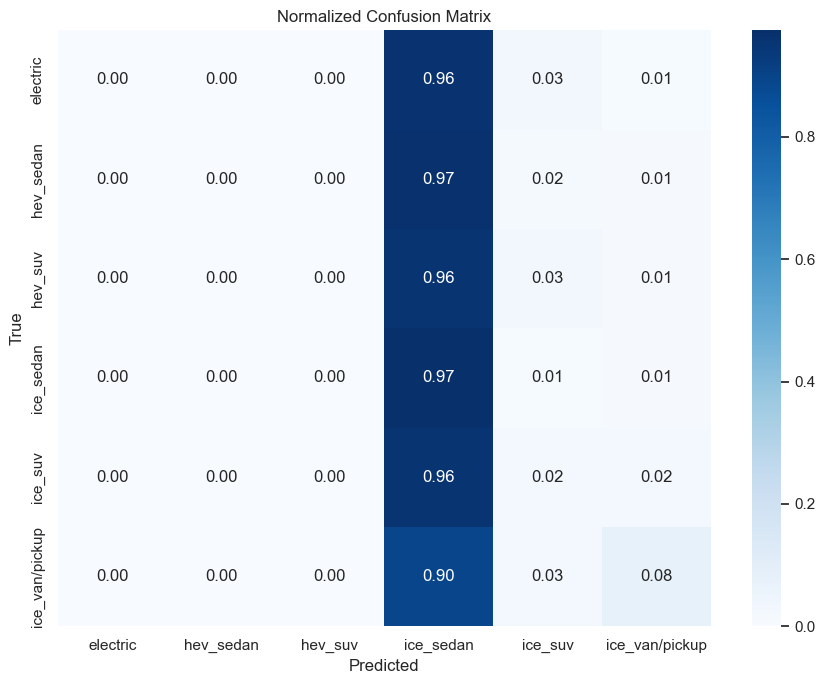

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    classification_report,
    confusion_matrix,
    top_k_accuracy_score,
)

# Reuse existing split if available; otherwise create it from df_model
if not all(v in globals() for v in ["X_test", "y_test"]):
    X = df_model[["fsa", "gender", "age_group", "AnneeSAAQ"]].copy()
    y = df_model["vehicle_type"].copy()
    _, X_test, _, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

# Predictions
y_pred = car_share_model.predict(X_test)
y_proba = car_share_model.predict_proba(X_test)
classes = car_share_model.named_steps["clf"].classes_

# Metrics
acc = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average="macro")
ll = log_loss(y_test, y_proba, labels=classes)
top2 = top_k_accuracy_score(y_test, y_proba, k=2, labels=classes)
top3 = top_k_accuracy_score(y_test, y_proba, k=3, labels=classes)

print("=== Model Evaluation ===")
print(f"Accuracy:           {acc:.4f}")
print(f"Balanced accuracy:  {bacc:.4f}")
print(f"Macro F1:           {f1m:.4f}")
print(f"Log-loss:           {ll:.4f}")
print(f"Top-2 accuracy:     {top2:.4f}")
print(f"Top-3 accuracy:     {top3:.4f}")

# Per-class report
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
display(report_df.round(4))

# Normalized confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=classes, normalize="true")

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    top_k_accuracy_score,
)

X_cv = df_model[["fsa", "gender", "age_group", "AnneeSAAQ"]].copy()
y_cv = df_model["vehicle_type"].copy()
all_classes = np.array(sorted(y_cv.unique()))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
    X_tr, X_va = X_cv.iloc[tr_idx], X_cv.iloc[va_idx]
    y_tr, y_va = y_cv.iloc[tr_idx], y_cv.iloc[va_idx]

    m = clone(car_share_model)
    m.fit(X_tr, y_tr)

    y_pred = m.predict(X_va)
    y_proba_fold = m.predict_proba(X_va)
    fold_classes = m.named_steps["clf"].classes_

    # Align fold probabilities to global class order
    proba_full = np.zeros((len(X_va), len(all_classes)), dtype=float)
    class_to_col = {c: i for i, c in enumerate(all_classes)}
    for j, c in enumerate(fold_classes):
        proba_full[:, class_to_col[c]] = y_proba_fold[:, j]

    rows.append({
        "fold": fold,
        "accuracy": accuracy_score(y_va, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_va, y_pred),
        "macro_f1": f1_score(y_va, y_pred, average="macro"),
        "log_loss": log_loss(y_va, proba_full, labels=all_classes),
        "top2_accuracy": top_k_accuracy_score(y_va, proba_full, k=2, labels=all_classes),
        "top3_accuracy": top_k_accuracy_score(y_va, proba_full, k=3, labels=all_classes),
    })

cv_results = pd.DataFrame(rows)
display(cv_results.round(4))

summary = cv_results.drop(columns=["fold"]).agg(["mean", "std"]).T
print("\n=== 5-Fold CV Summary (mean ± std) ===")
for metric, r in summary.iterrows():
    print(f"{metric:18s}: {r['mean']:.4f} ± {r['std']:.4f}")

/Users/natomanzolli/opt/anaconda3/envs/bus_charging_app/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
# --- Plots for 2021 predicted vehicle shares ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# Use in-memory predictions if available; otherwise load saved CSV
if "pred_long" not in globals():
    pred_long = pd.read_csv(
        "/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model/predicted_car_share_2021_all_fsa_gender_age.csv"
    )

plot_df = pred_long.copy()
plot_df["predicted_share_pct"] = plot_df["predicted_share"] * 100.0

# 1) Overall mean share by vehicle type
overall = (
    plot_df.groupby("vehicle_type", as_index=False)["predicted_share_pct"]
    .mean()
    .sort_values("predicted_share_pct", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=overall, x="vehicle_type", y="predicted_share_pct", palette="tab10")
plt.title("2021 Mean Predicted Share by Vehicle Type (All FSA/Gender/Age)")
plt.xlabel("Vehicle type")
plt.ylabel("Predicted share (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# 2) Mean share by gender (stacked)
by_gender = (
    plot_df.groupby(["gender", "vehicle_type"], as_index=False)["predicted_share_pct"]
    .mean()
)
pivot_gender = by_gender.pivot(index="gender", columns="vehicle_type", values="predicted_share_pct").fillna(0)

pivot_gender.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="tab20")
plt.title("2021 Mean Predicted Share by Gender")
plt.xlabel("Gender")
plt.ylabel("Predicted share (%)")
plt.legend(title="Vehicle type", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 3) Top FSAs by electric share (mean across gender+age)
electric_fsa = (
    plot_df[plot_df["vehicle_type"] == "electric"]
    .groupby("fsa", as_index=False)["predicted_share_pct"]
    .mean()
    .sort_values("predicted_share_pct", ascending=False)
)

top_n = 20
top_electric = electric_fsa.head(top_n)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_electric, x="fsa", y="predicted_share_pct", color="#2a9d8f")
plt.title(f"Top {top_n} FSAs by Predicted Electric Share (2021)")
plt.xlabel("FSA")
plt.ylabel("Predicted electric share (%)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# 4) Heatmap: age group x vehicle type (mean across FSAs), for each gender
for g in sorted(plot_df["gender"].dropna().unique()):
    hm = (
        plot_df[plot_df["gender"] == g]
        .groupby(["age_group", "vehicle_type"], as_index=False)["predicted_share_pct"]
        .mean()
        .pivot(index="age_group", columns="vehicle_type", values="predicted_share_pct")
        .fillna(0)
    )

    plt.figure(figsize=(10, 5))
    sns.heatmap(hm, annot=True, fmt=".1f", cmap="YlGnBu")
    plt.title(f"2021 Mean Predicted Share (%) — Age Group × Vehicle Type ({g})")
    plt.xlabel("Vehicle type")
    plt.ylabel("Age group")
    plt.tight_layout()
    plt.show()